# Exploratory Data Analysis

Logan Wong

law3082

In [1]:
import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

In [2]:
# Redirect HuggingFace cache to avoid Disk Quota Exceeded errors
os.environ['HF_HOME'] = '/tmp/law3082_hf'

# Load Data

In [3]:
# Load the data generated by preprocess.py
df = pd.read_csv('./twitter-incremental-clustering/event2012.tsv', sep='\t')

# Display first few rows
# COLUMNS: id, text, created_at, label
print(f"Loaded {len(df)} tweets.")
df.head()

Loaded 68841 tweets.


,id,text,created_at,label
0,256292946331181056,Nobel prize in literature to be announced http...,2012-10-11 07:19:34,0
1,256333064467279872,“@marvicleonen: Is it true that UP won UAAP ba...,2012-10-11 09:58:59,0
2,256334302034399232,"Congrats, Ateneo! Last na yan ha. Season 76 wi...",2012-10-11 10:03:54,0
3,256335853738160128,"""@SMARTPromos: SMART never wants you to be lef...",2012-10-11 10:10:04,0
4,256346272506712064,CCTV invite hints at Nobel literature prize fo...,2012-10-11 10:51:28,0


Event2012: <br>
150K english tweet IDS <br>
related 506 distinct events <br>
over 4 weeks <br>

They preprocessed it to be: <br>
68841 tweets <br>
related to 503 events <br>

So it takes place over 1 month in 2012

In [4]:
# There should be 503 events aka 503 class labels

n = df['label'].nunique()
# How many unique events are there?
print(f"Unique Events (Labels): {n}")

Unique Events (Labels): 503


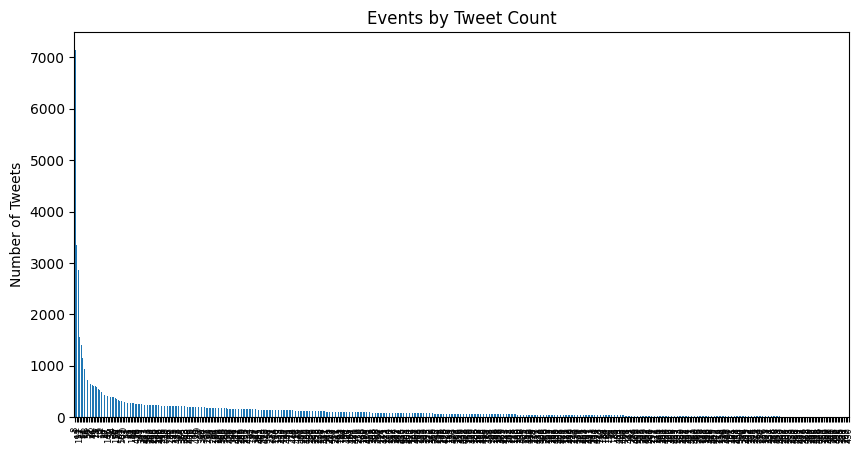

/tmp/ipykernel_264800/223252688.py:12: FutureWarning: The behavior of `series[i:j]` with an integer-dtype index is deprecated. In a future version, this will be treated as *label-based* indexing, consistent with e.g. `series[i]` lookups. To retain the old behavior, use `series.iloc[i:j]`. To get the future behavior, use `series.loc[i:j]`.
  df['label'].value_counts()[i:i+100].plot(kind='bar')


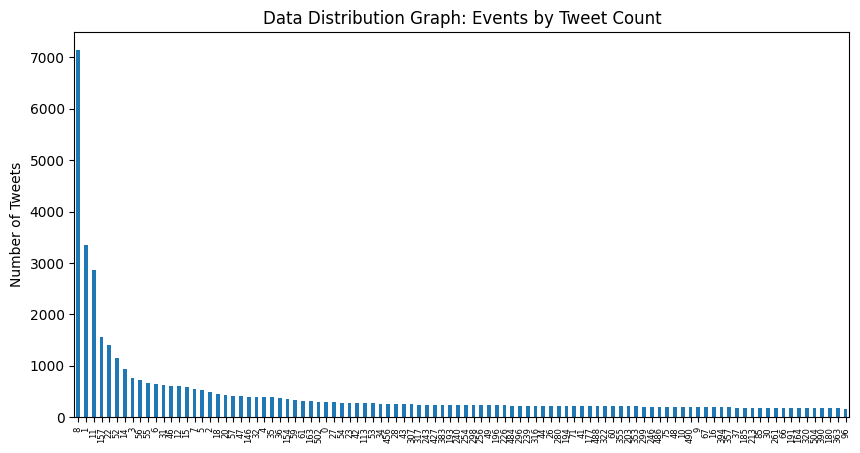

/tmp/ipykernel_264800/223252688.py:12: FutureWarning: The behavior of `series[i:j]` with an integer-dtype index is deprecated. In a future version, this will be treated as *label-based* indexing, consistent with e.g. `series[i]` lookups. To retain the old behavior, use `series.iloc[i:j]`. To get the future behavior, use `series.loc[i:j]`.
  df['label'].value_counts()[i:i+100].plot(kind='bar')


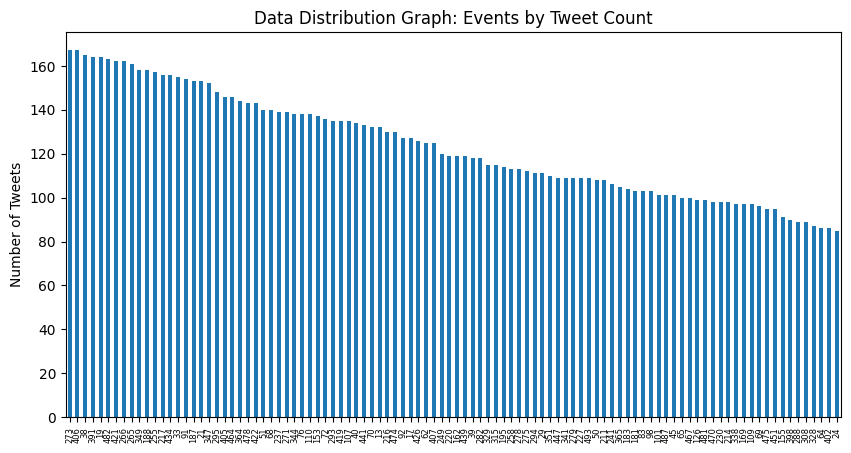

/tmp/ipykernel_264800/223252688.py:12: FutureWarning: The behavior of `series[i:j]` with an integer-dtype index is deprecated. In a future version, this will be treated as *label-based* indexing, consistent with e.g. `series[i]` lookups. To retain the old behavior, use `series.iloc[i:j]`. To get the future behavior, use `series.loc[i:j]`.
  df['label'].value_counts()[i:i+100].plot(kind='bar')


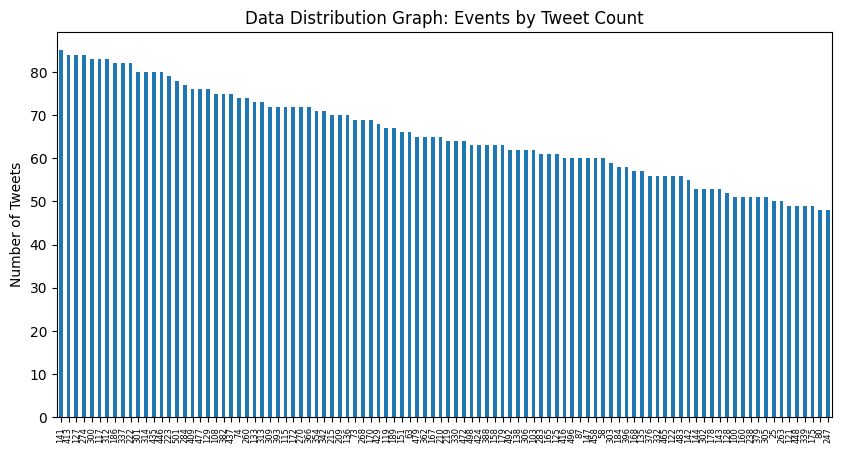

/tmp/ipykernel_264800/223252688.py:12: FutureWarning: The behavior of `series[i:j]` with an integer-dtype index is deprecated. In a future version, this will be treated as *label-based* indexing, consistent with e.g. `series[i]` lookups. To retain the old behavior, use `series.iloc[i:j]`. To get the future behavior, use `series.loc[i:j]`.
  df['label'].value_counts()[i:i+100].plot(kind='bar')


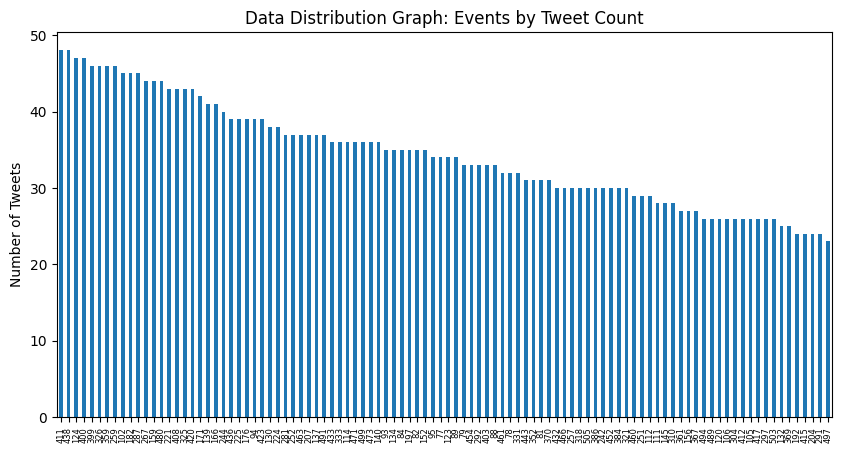

/tmp/ipykernel_264800/223252688.py:12: FutureWarning: The behavior of `series[i:j]` with an integer-dtype index is deprecated. In a future version, this will be treated as *label-based* indexing, consistent with e.g. `series[i]` lookups. To retain the old behavior, use `series.iloc[i:j]`. To get the future behavior, use `series.loc[i:j]`.
  df['label'].value_counts()[i:i+100].plot(kind='bar')


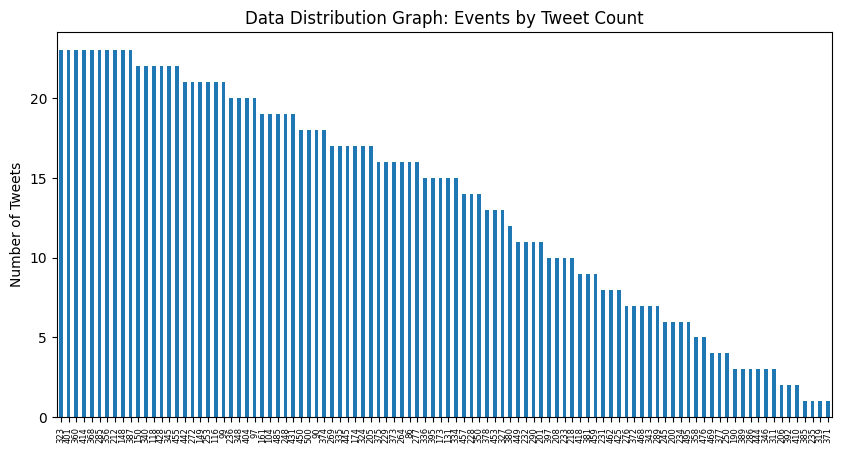

/tmp/ipykernel_264800/223252688.py:12: FutureWarning: The behavior of `series[i:j]` with an integer-dtype index is deprecated. In a future version, this will be treated as *label-based* indexing, consistent with e.g. `series[i]` lookups. To retain the old behavior, use `series.iloc[i:j]`. To get the future behavior, use `series.loc[i:j]`.
  df['label'].value_counts()[i:i+100].plot(kind='bar')


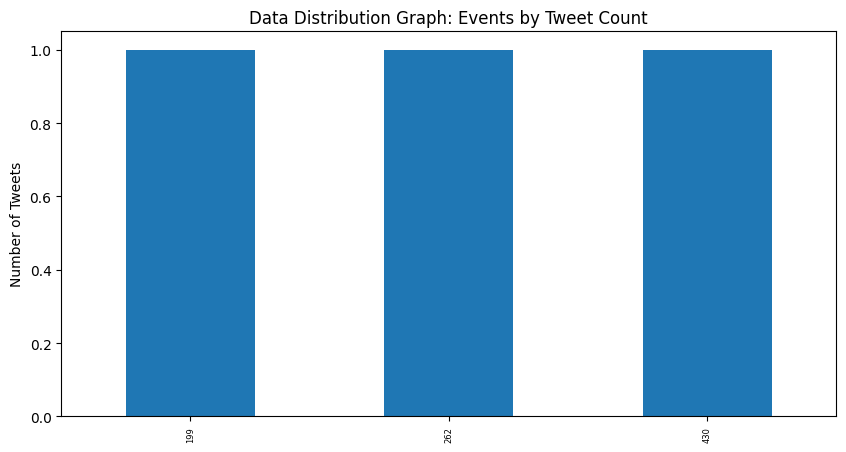

In [12]:
# how the total number of tweets is spread out across 20 event labels
plt.figure(figsize=(10, 5))
df['label'].value_counts().plot(kind='bar')
plt.title("Events by Tweet Count")
plt.ylabel("Number of Tweets")
plt.tick_params(axis='x', labelsize=6)
plt.show()

# Plot in chunks of 100
for i in range(0, 503, 100):
    plt.figure(figsize=(10, 5))
    df['label'].value_counts()[i:i+100].plot(kind='bar')
    plt.title("Data Distribution Graph: Events by Tweet Count")
    plt.ylabel("Number of Tweets")
    plt.tick_params(axis='x', labelsize=6)
    plt.show()

In [6]:
# PRINT a few tweets that belong to the most frequent event, and least frequent events

# Count how many times each label appears
counts = df['label'].value_counts()

# Get the IDs for the largest and smallest
largest_id = counts.index[0]
smallest_ids = counts[counts == 1].index[:]

print(f"Largest Event (ID: {largest_id}, Count: {counts[largest_id]})")
print(df[df['label'] == largest_id]['text'].head(5).values)

print(f"\nSmallest Events (IDs: {list(smallest_ids)}, Length: {len(smallest_ids)}, Count: 1 each)")
for s_id in smallest_ids:
    print(f"Event {s_id}: {df[df['label'] == s_id]['text'].values[0]}")

Largest Event (ID: 8, Count: 7133)
['Debate comes on to tonight !!!!!! #Obama'
 'Debate Tonight TurnUp Tuesday @9pm. I just got of the phone Obama ! He Said "I got this my Brother" #2terms'
 'Photoset: Hempstead, NY Obama-Romney 2nd debate http://t.co/XDb95u6e'
 'Do you think #Obama will be able to rebound tonight? Or will #Romney keep his momentum going?'
 'If it gets to tough for Obama, he can always hide behind Crowley.']

Smallest Events (IDs: [262, 319, 235, 385, 199, 371, 430], Length: 7, Count: 1 each)
Event 262: Spanish novelist Javier Marías turns down €20,000 government prize: Author of The Infatuations says he does not ... http://t.co/XY8ZqrnB
Event 319: Its confirmed apparently they are in dublin
Event 235: Plz flw @HipHoptimum: #Sony sued over William Faulkner quote in ‘Midnight in Paris’ -  Sony... http://t.co/wbkMW5ju
 #newtag #paris
Event 385: N. Korean defector simply walked through DMZ and passed border fences to S. Korea, unchecked. http://t.co/A7AuoVos
Event 199: 4:

# Data vs Time

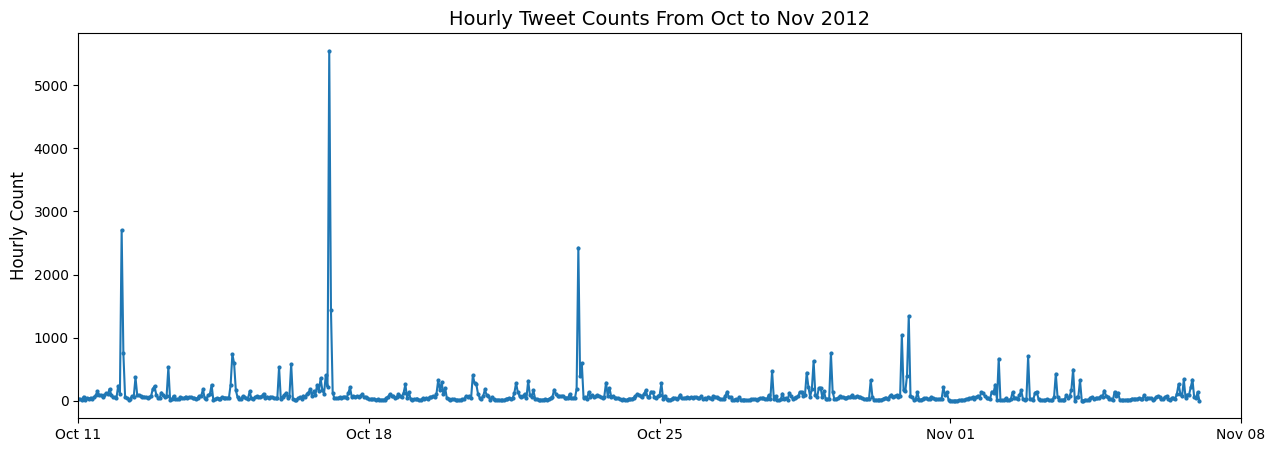

In [7]:
df['created_at'] = pd.to_datetime(df['created_at'])
df = df.sort_values('created_at')

# Set index and resample
hourly_counts = df.set_index('created_at').resample('1H').size()

# Plot
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(hourly_counts.index, hourly_counts.values, 'o-', markersize=2)

# Set labels and title
ax.set_ylabel('Hourly Count', fontsize=12)
ax.set_title('Hourly Tweet Counts From Oct to Nov 2012', fontsize=14)

# Force the x-axis limits to your actual date range
ax.set_xlim(pd.Timestamp('2012-10-11'), pd.Timestamp('2012-11-8'))

# Now set weekly ticks
ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
# plt.xticks(rotation=45)
plt.show()

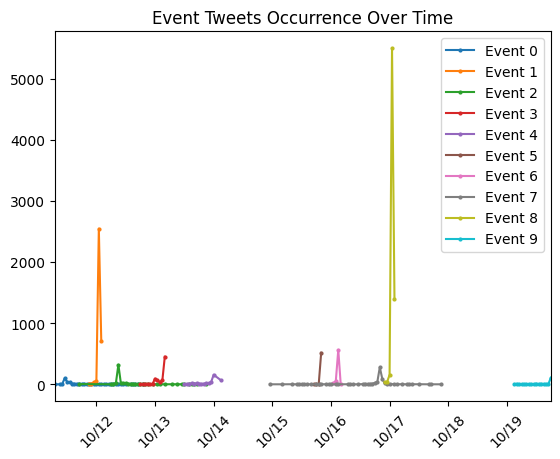

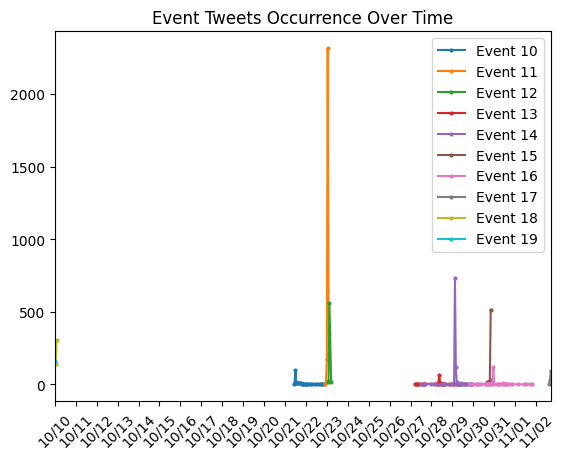

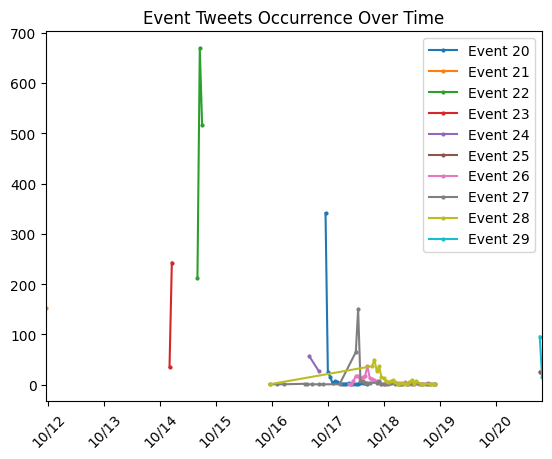

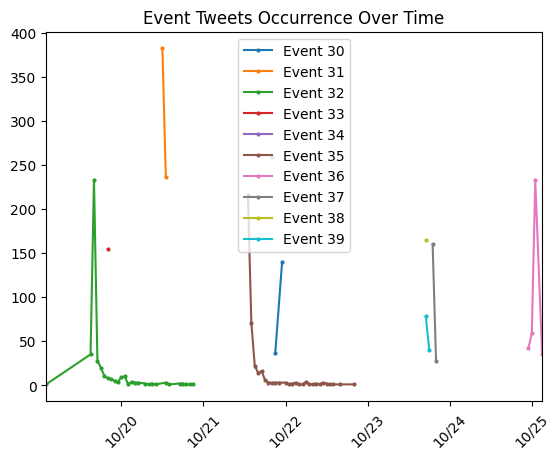

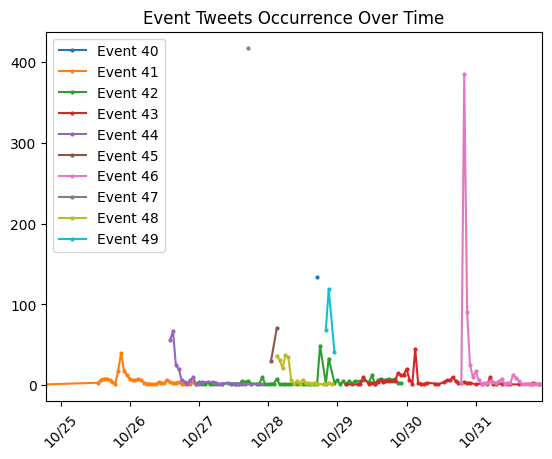

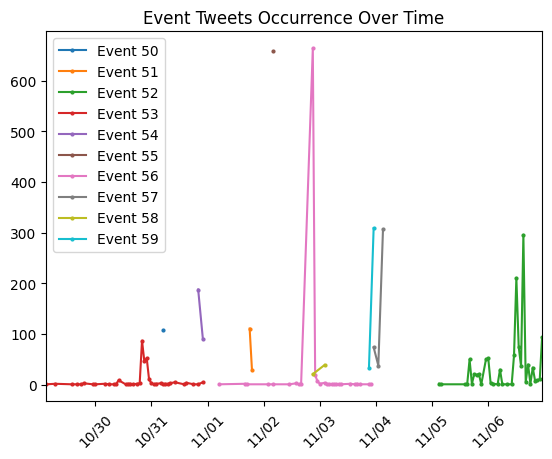

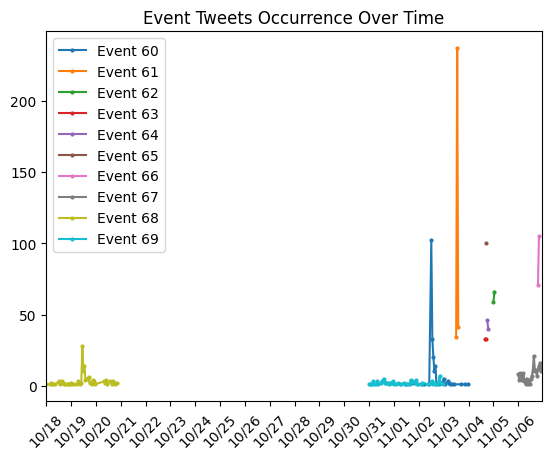

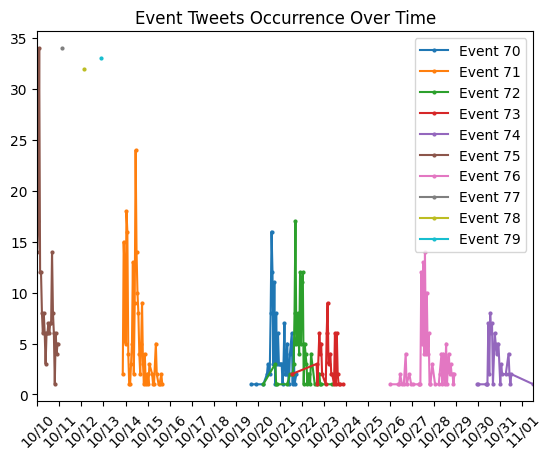

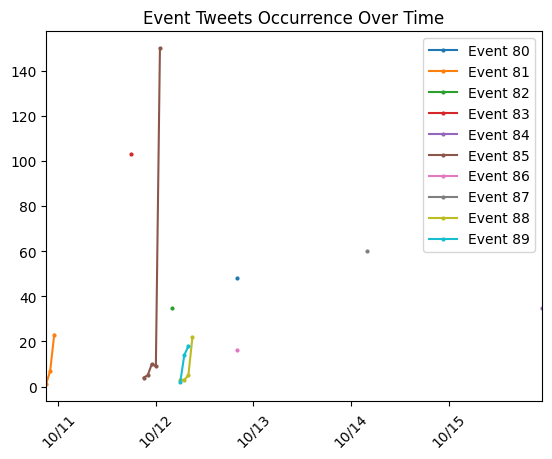

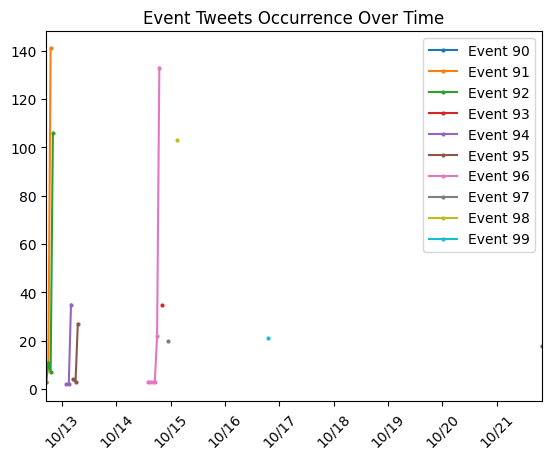

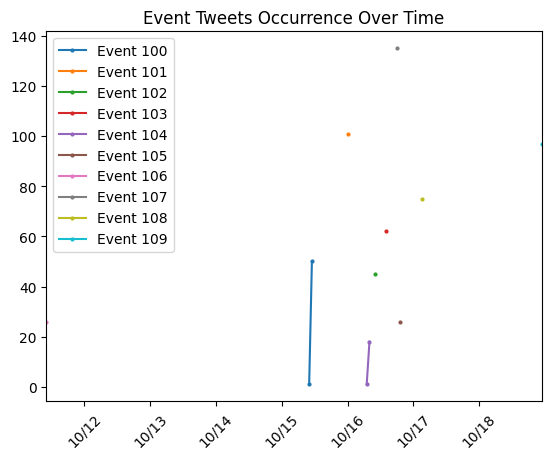

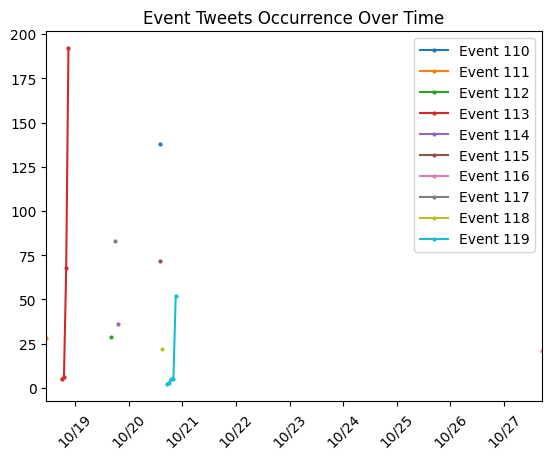

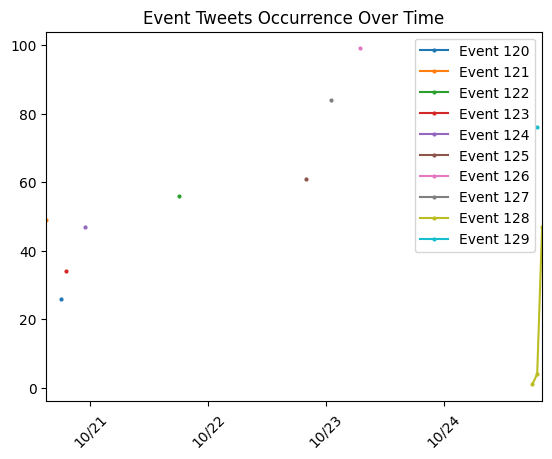

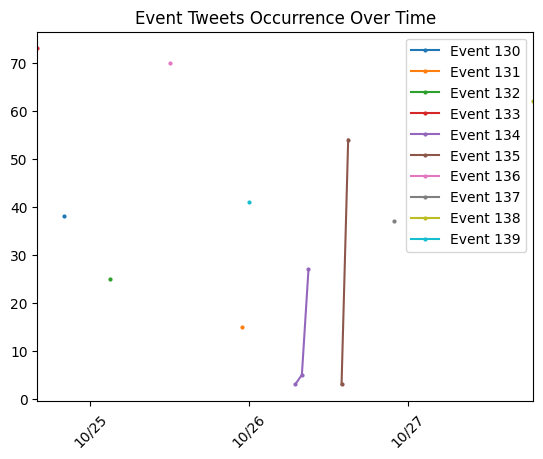

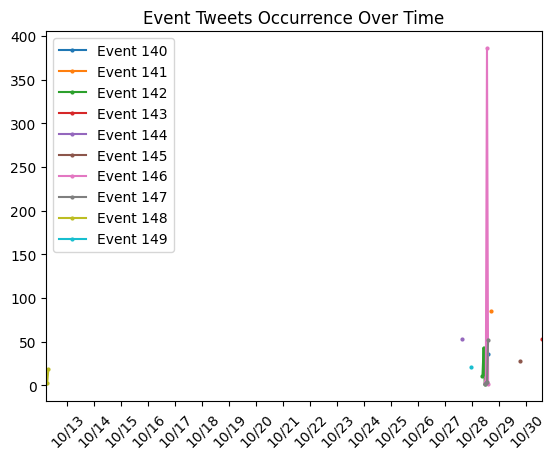

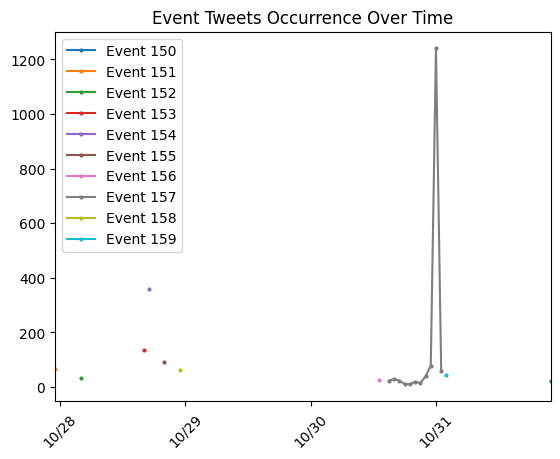

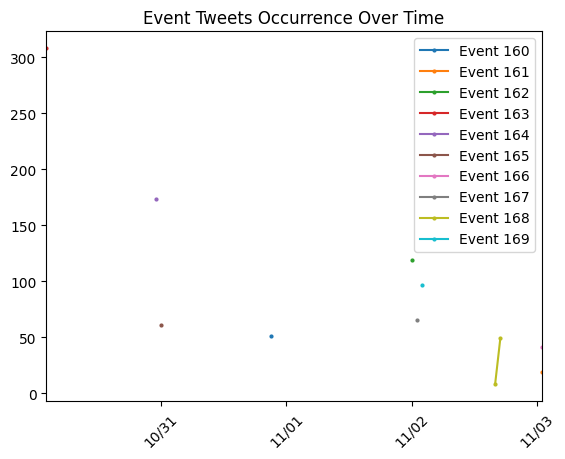

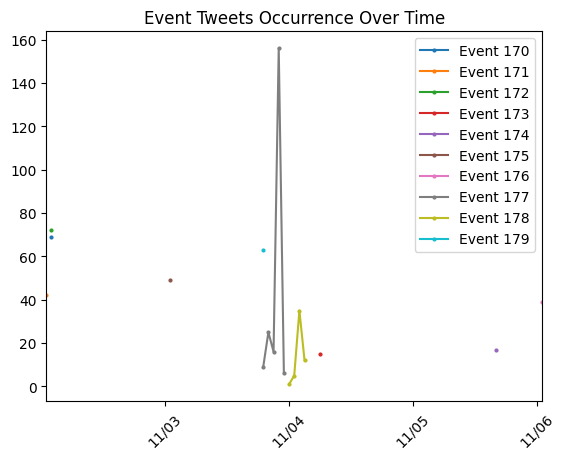

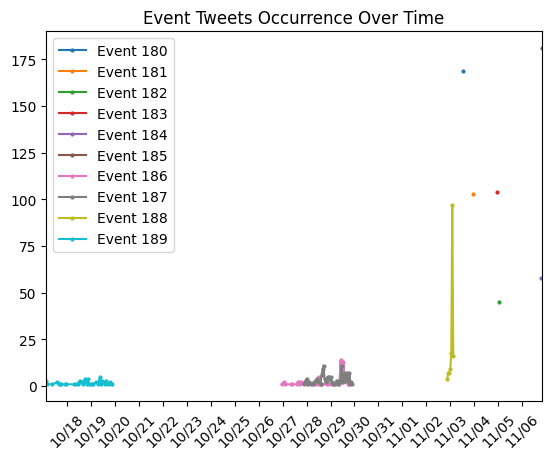

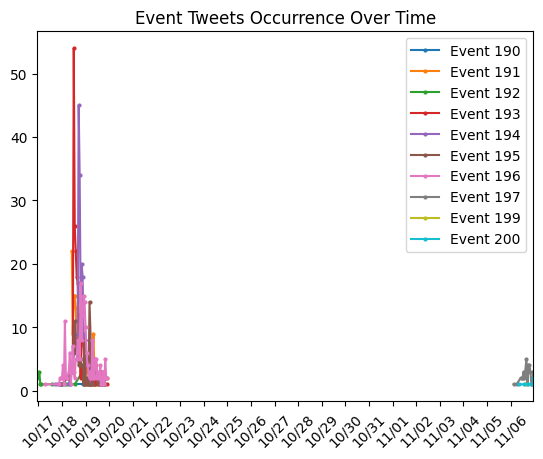

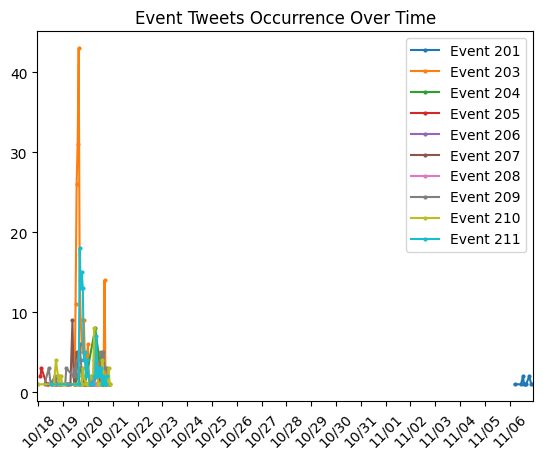

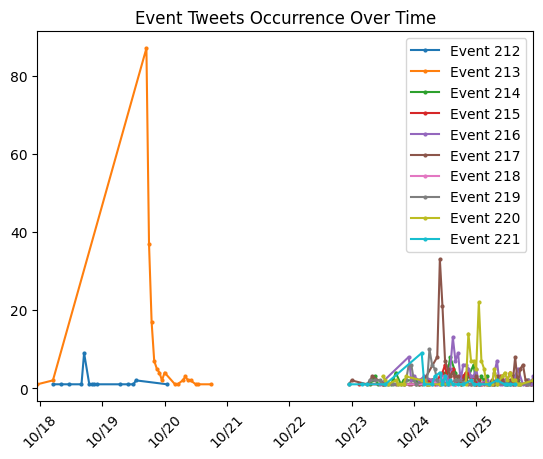

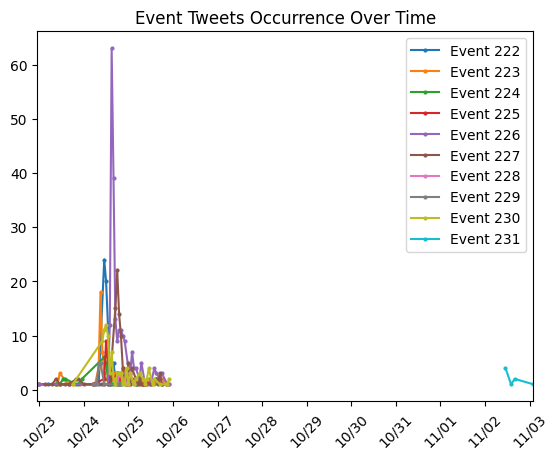

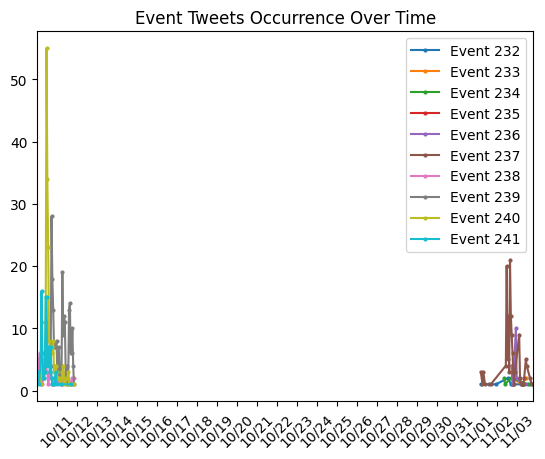

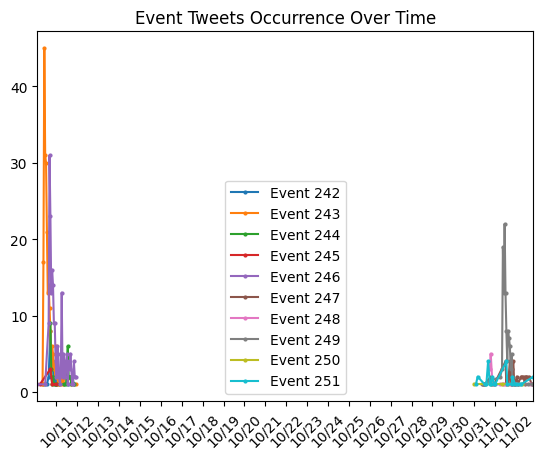

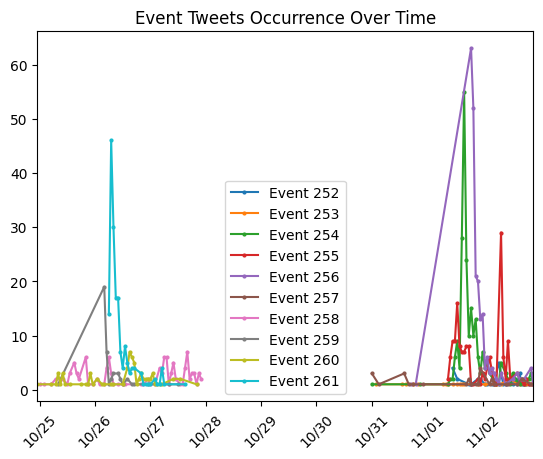

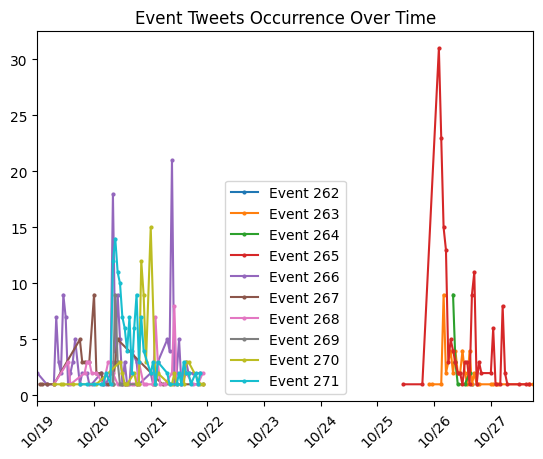

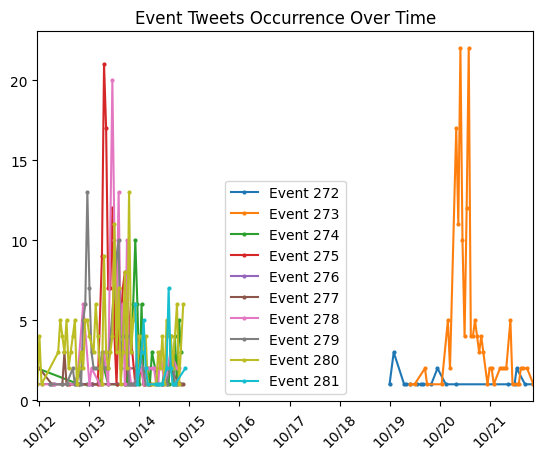

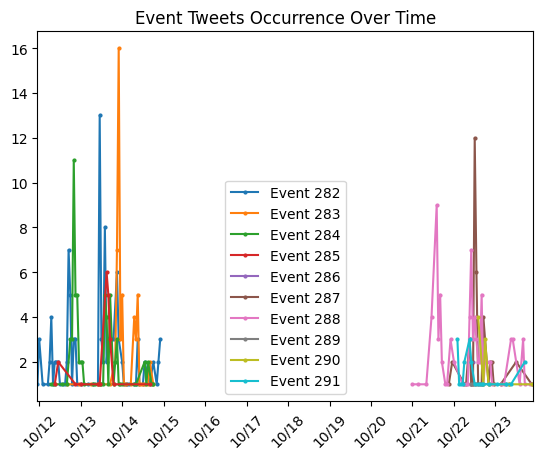

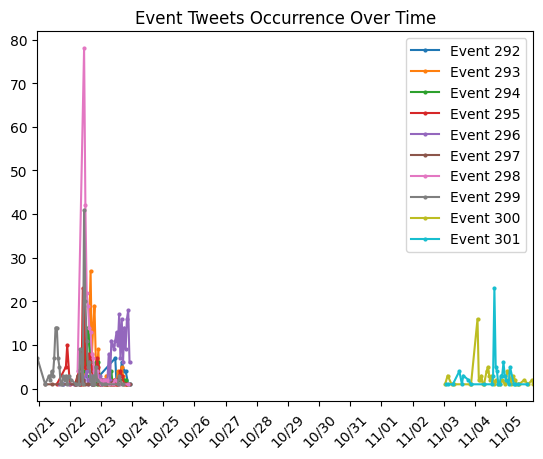

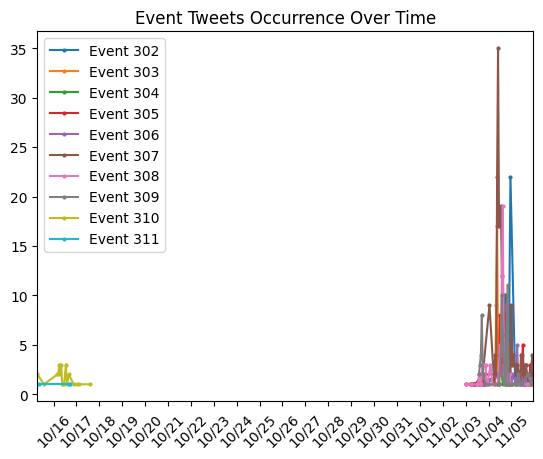

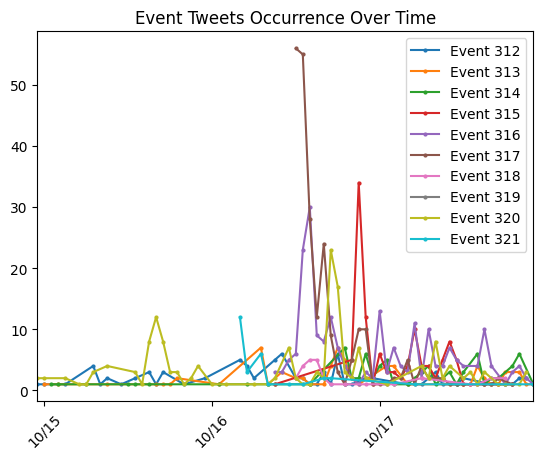

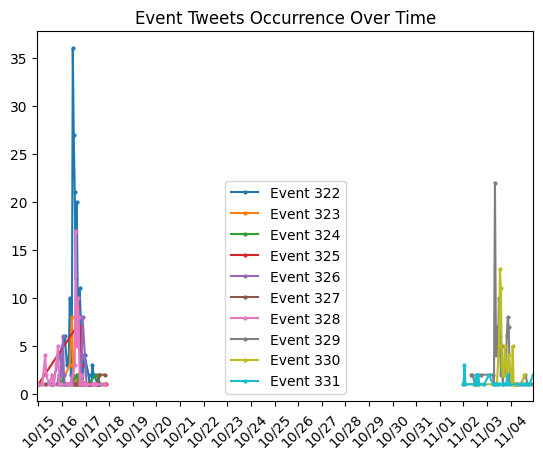

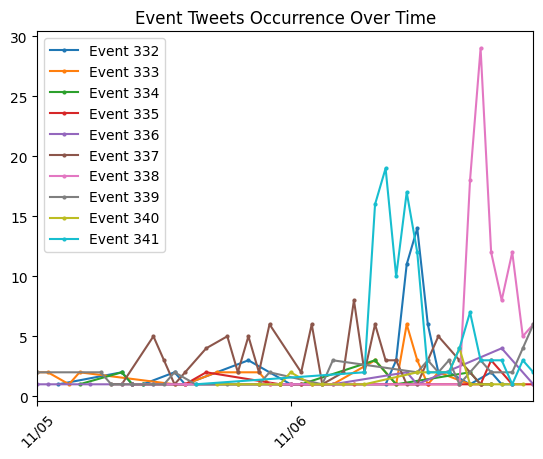

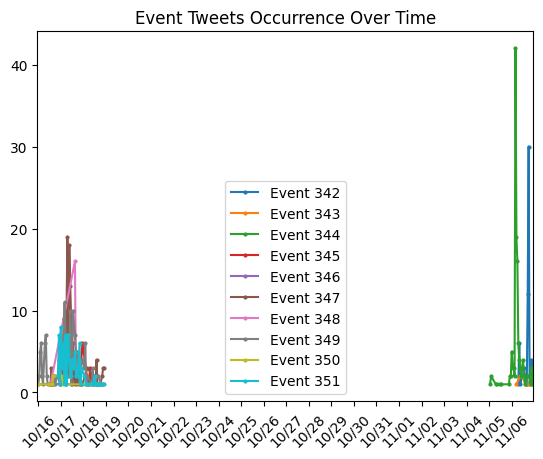

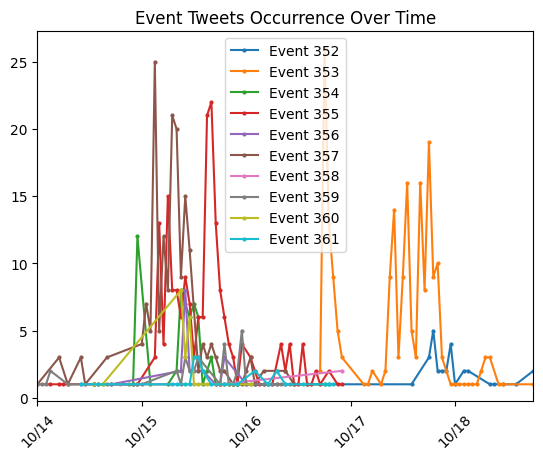

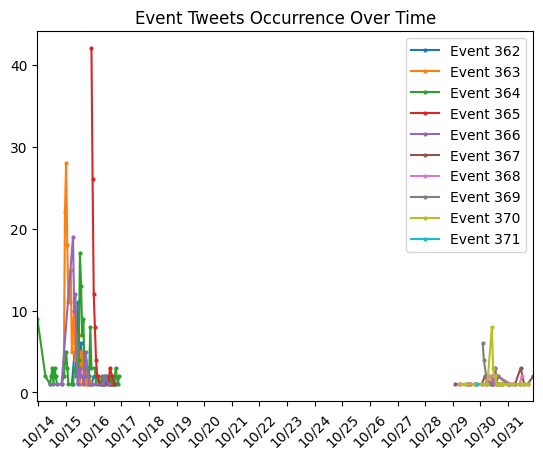

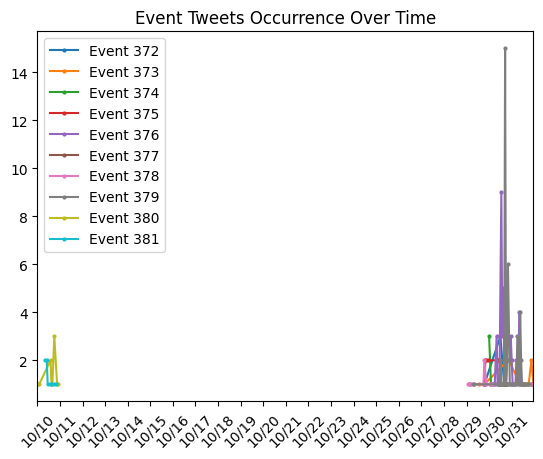

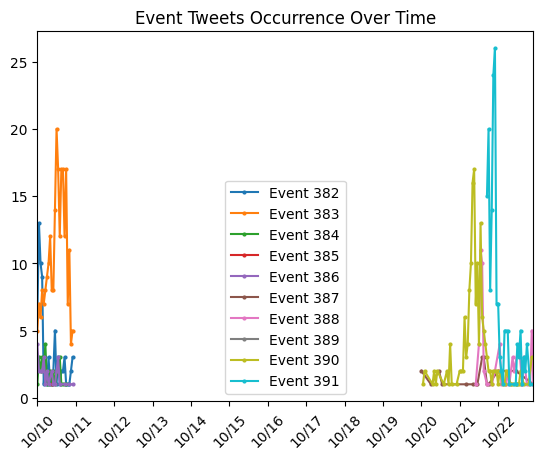

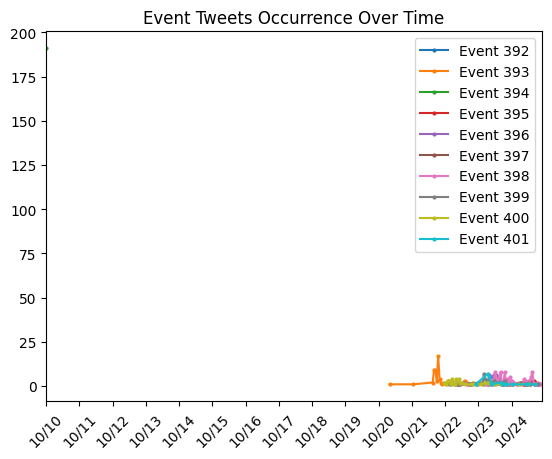

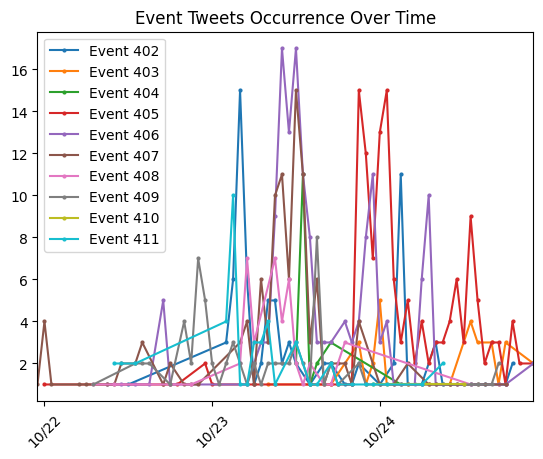

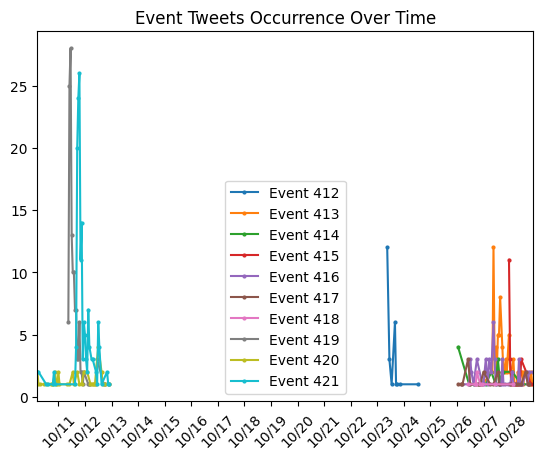

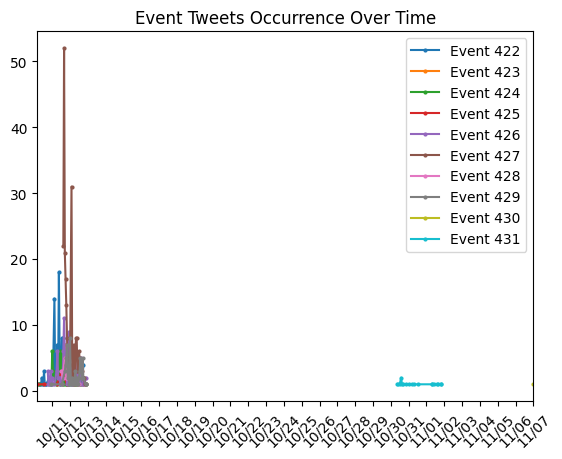

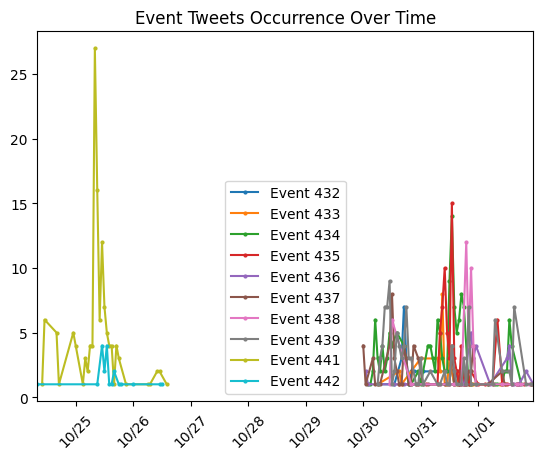

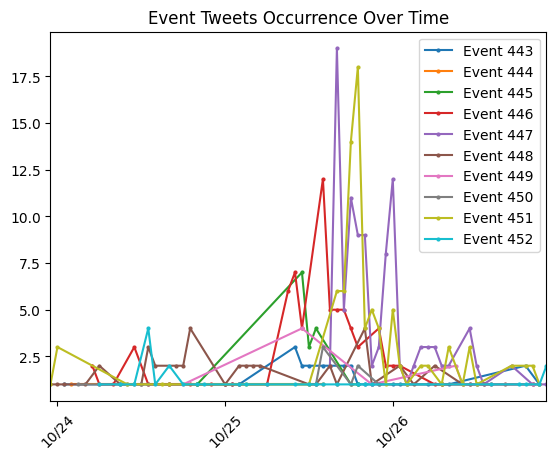

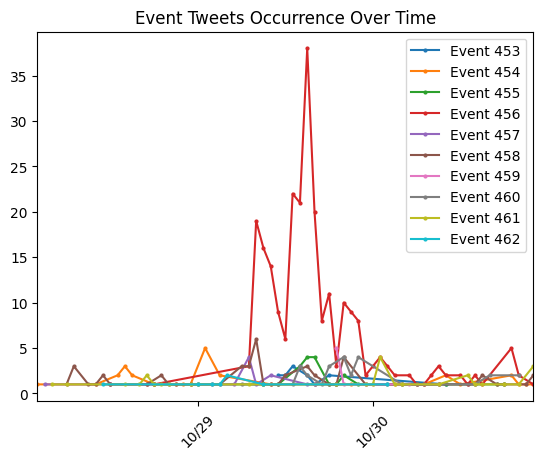

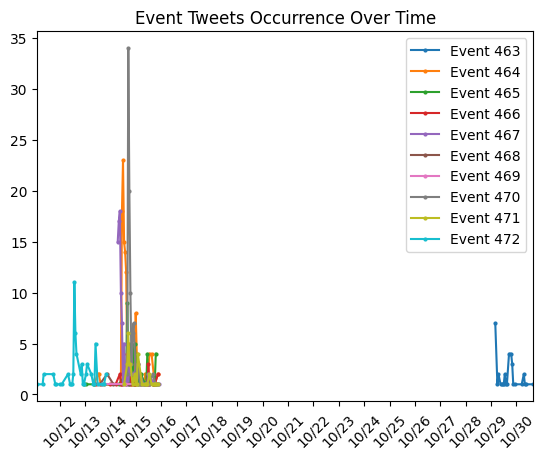

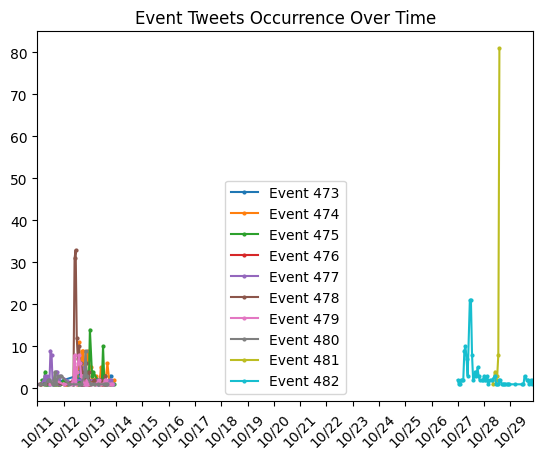

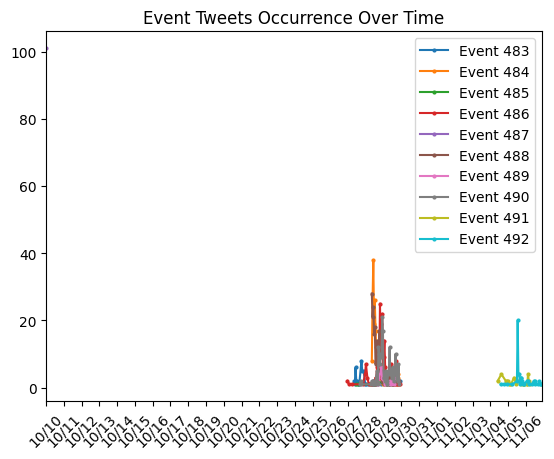

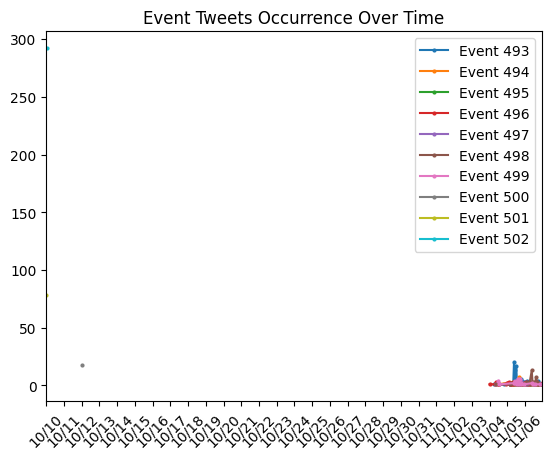

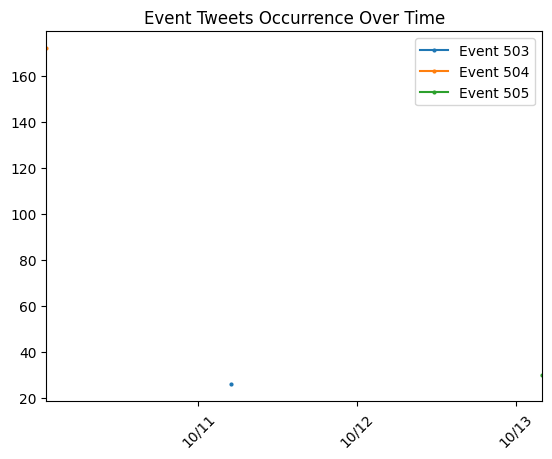

In [8]:
# Distribution by label over time
existing_labels = sorted(df['label'].unique())

# Sliding window to show every 10 events
for j in range(0, len(existing_labels), 10):
    fig, ax = plt.subplots()

    all_dates = []

    # Only show 10 events at a time
    for label in existing_labels[j:j+10]:
        df_pos = df[df['label']==label].set_index('created_at').resample('1H').size()
        df_pos = df_pos[df_pos > 0]
        
        ax.plot(df_pos.index, df_pos.values, label=f'Event {label}', marker='o', markersize=2)
        all_dates.extend(df_pos.index)

    if all_dates:
        ax.set_xlim(min(all_dates), max(all_dates))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
    
    ax.legend()
    ax.set_title('Event Tweets Occurrence Over Time')
    plt.xticks(rotation=45)
    plt.show()

Text(0.5, 1.0, 'Tweet Volume by Hour')

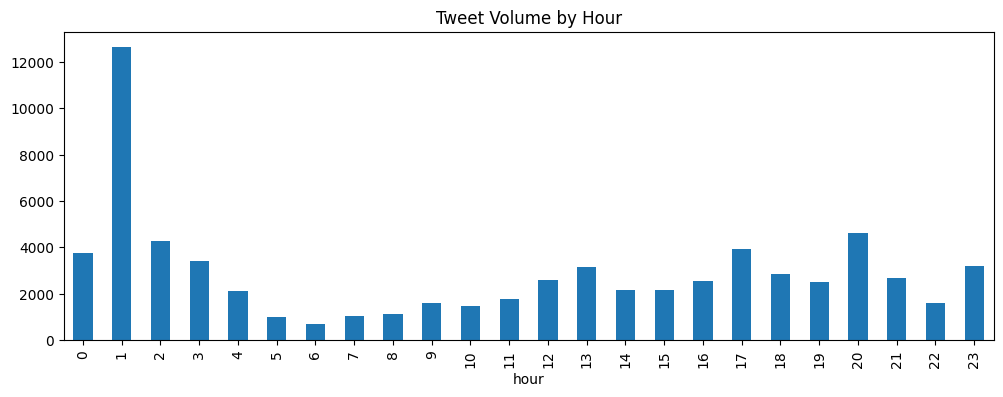

In [9]:
# Extract hour and analyze tweet volume by hour of day
df['hour'] = df['created_at'].dt.hour
hourly_pattern = df.groupby('hour').size()
hourly_pattern.plot(kind='bar', figsize=(12,4))
plt.title('Tweet Volume by Hour')

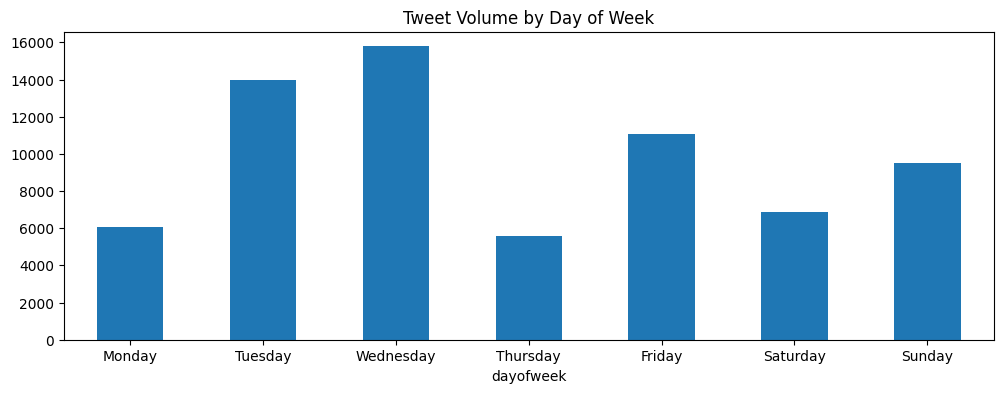

In [10]:
week_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

df['dayofweek'] = df['created_at'].dt.day_name()
# Convert to categorical with specified order
df['dayofweek'] = pd.Categorical(df['dayofweek'], categories=week_order, ordered=True)

daily_pattern = df.groupby('dayofweek', observed=False).size()
daily_pattern.plot(kind='bar', figsize=(12,4))
plt.title('Tweet Volume by Day of Week')
plt.xticks(rotation=0)
plt.show()

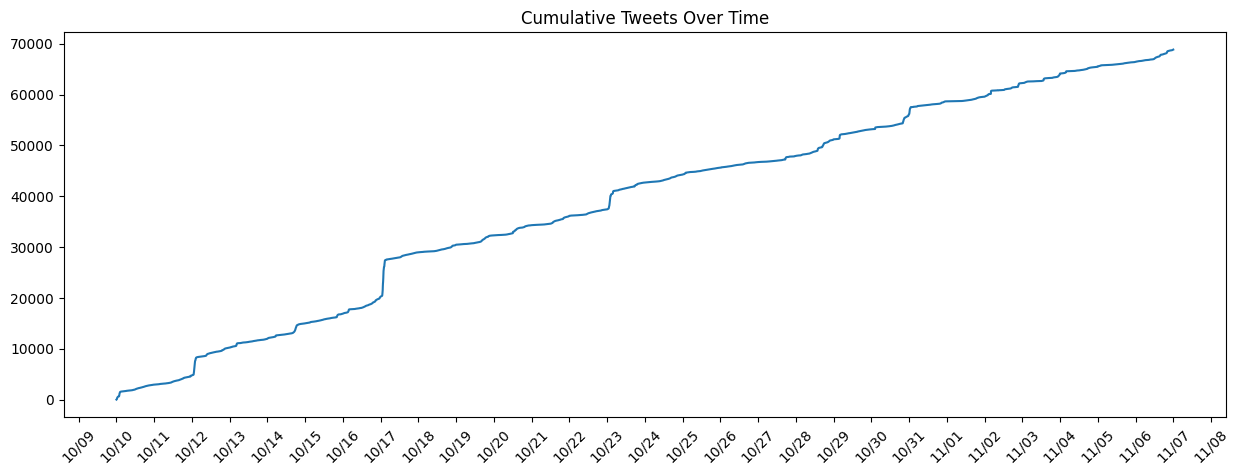

In [11]:
# Show cumulative number of tweets over time aka RUNNING TOTAL
# Shows how the tweet count grows from the 1st to the last tweet.
    
df_sorted = df.sort_values('created_at')
df_sorted['cumulative_count'] = range(1, len(df_sorted)+1)

fig, ax = plt.subplots(figsize=(15, 5))
plt.plot(df_sorted['created_at'], df_sorted['cumulative_count'])

# Tick every day
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))

plt.title('Cumulative Tweets Over Time')
plt.xticks(rotation=45)
plt.show()

# It progressively goes up, but varies in steepness.
# Steeper = tweets appear at a higher velocity
# Flatter = tweets appear at a lower velocity